# Hito 3 - Pipeline de Preprocesamiento y Ajuste de Hiperparametros
## GuardianAI - Deteccion Inteligente de Fraude Bancario

## Indice

1. Importacion de librerias
2. Carga y particion de datos (70/15/15)
3. Pipeline de preprocesamiento con SMOTE
   - 3.1. Codificacion de variables categoricas
   - 3.2. Escalado de variables numericas continuas
   - 3.3. Aplicacion de SMOTE
4. Modelo XGBoost base (referencia de partida)
5. Busqueda de hiperparametros optimos
   - 5.1. Espacio de busqueda y justificacion
   - 5.2. RandomizedSearchCV sobre XGBoost, Random Forest y Regresion Logistica
6. Evaluacion individual de los modelos optimizados
7. Comparativa final de todos los modelos optimizados
8. Importancia de caracteristicas del mejor modelo
9. Evaluacion final sobre el conjunto de test real

## 1. Importacion de librerias

In [8]:
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    roc_curve, precision_recall_curve, auc,
    confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

os.makedirs('../figures', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10
})

## 2. Carga y particion de datos (70/15/15)

En NB02 se usaba una particion 80/20 adecuada para la comparativa inicial de modelos. En esta fase de optimizacion se cambia a **70/15/15** para disponer de tres conjuntos con roles bien diferenciados:

- **Train (70%)**: datos sobre los que se aplica SMOTE y se entrena cada modelo.
- **Validacion (15%)**: datos que ningun modelo ve durante el entrenamiento. `RandomizedSearchCV` los usa internamente para puntuar cada combinacion de hiperparametros durante la busqueda.
- **Test (15%)**: datos apartados desde el principio que no participan en ningun paso del entrenamiento ni de la busqueda. Conservan el desbalanceo original (~1.1% de fraudes) y representan las condiciones reales de operacion. **Las metricas finales se calculan exclusivamente sobre este conjunto.**

> Evaluar el modelo sobre los datos de entrenamiento, o sobre datos balanceados por SMOTE, produce metricas artificialmente perfectas que no reflejan el rendimiento real. Ese fue el error del notebook original que reportaba valores superiores al 98%.

In [9]:
df = pd.read_csv('Base.csv')
df = df.drop(columns=['credit_risk_score'])  # eliminado: causaria data leakage

X = df.drop(columns=['fraud_bool'])
y = df['fraud_bool']

# Primera particion: 70% train, 30% temporal
X_train_70, X_temp, y_train_70, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Segunda particion: mitad del temporal -> 15% val, 15% test
X_val_15, X_test_15, y_val_15, y_test_15 = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print('Tamanos de cada particion:')
print(f'  Train:      {len(X_train_70):,} registros  (fraude: {y_train_70.mean()*100:.2f}%)')
print(f'  Validacion: {len(X_val_15):,} registros  (fraude: {y_val_15.mean()*100:.2f}%)')
print(f'  Test:       {len(X_test_15):,} registros  (fraude: {y_test_15.mean()*100:.2f}%)')

Tamanos de cada particion:
  Train:      700,000 registros  (fraude: 1.10%)
  Validacion: 150,000 registros  (fraude: 1.10%)
  Test:       150,000 registros  (fraude: 1.10%)


## 3. Pipeline de preprocesamiento con SMOTE

El preprocesamiento se aplica **unicamente al conjunto de train**, en este orden:

1. Codificacion de variables categoricas (one-hot encoding).
2. Escalado de variables **continuas** con `StandardScaler`, ajustado solo sobre train y aplicado luego a val y test.
3. SMOTE sobre los datos de train ya codificados y escalados.

Val y test **no se tocan con SMOTE**: deben mantener el desbalanceo original para que la evaluacion sea realista.

### 3.1. Codificacion de variables categoricas

`pd.get_dummies` convierte cada valor de una variable categorica en una columna binaria (0 o 1). Por ejemplo, la variable `payment_type` con valores AA, AB, AC... se convierte en columnas `payment_type_AB`, `payment_type_AC`, etc. Despues se alinean val y test para que tengan exactamente las mismas columnas que train, ya que puede haber categorias que no aparezcan en todas las particiones.

In [10]:
X_train_enc = pd.get_dummies(X_train_70, drop_first=True)
X_val_enc   = pd.get_dummies(X_val_15,   drop_first=True)
X_test_enc  = pd.get_dummies(X_test_15,  drop_first=True)

# Alinear columnas: val y test deben tener exactamente las mismas que train
X_val_enc  = X_val_enc.reindex(columns=X_train_enc.columns,  fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print(f'Columnas tras one-hot encoding: {X_train_enc.shape[1]}')

Columnas tras one-hot encoding: 46


### 3.2. Escalado de variables numericas continuas

`StandardScaler` resta la media y divide entre la desviacion tipica, dejando cada variable con media 0 y desviacion 1. Esto es necesario para que variables con rangos muy distintos (por ejemplo `velocity_6h` puede ir de -175 a 16818, mientras que `income` va de 0.1 a 0.9) no dominen el aprendizaje.

**Importante**: solo se escalan las variables que son realmente continuas. Las columnas generadas por one-hot encoding (como `device_os_windows` o `payment_type_AB`) ya son binarias (0 o 1) y **no deben escalarse**: escalarlas distorsiona sus valores y puede hacer que el modelo les asigne un peso incorrecto. En la ejecucion anterior sin este filtro, `device_os_windows` aparecia como la variable mas importante con un 30% — un resultado sin sentido que desaparece al corregir el escalado.

El scaler se ajusta (`fit`) solo sobre train. Si se ajustase sobre val o test se estaria usando informacion estadistica de datos futuros, lo que invalida la evaluacion.

In [11]:
# Solo se escalan las variables con rango amplio de valores (continuas)
# Las columnas OHE (0/1) se dejan sin tocar
columnas_continuas = [
    'income', 'name_email_similarity', 'prev_address_months_count',
    'current_address_months_count', 'customer_age', 'days_since_request',
    'intended_balcon_amount', 'zip_count_4w', 'velocity_6h',
    'velocity_24h', 'velocity_4w', 'bank_branch_count_8w',
    'date_of_birth_distinct_emails_4w', 'bank_months_count',
    'proposed_credit_limit', 'session_length_in_minutes',
    'device_distinct_emails_8w', 'device_fraud_count', 'month'
]

# Quedarse solo con las que existen tras el encoding
columnas_continuas = [c for c in columnas_continuas if c in X_train_enc.columns]

scaler = StandardScaler()
scaler.fit(X_train_enc[columnas_continuas])

X_train_enc[columnas_continuas] = scaler.transform(X_train_enc[columnas_continuas])
X_val_enc[columnas_continuas]   = scaler.transform(X_val_enc[columnas_continuas])
X_test_enc[columnas_continuas]  = scaler.transform(X_test_enc[columnas_continuas])

print(f'Columnas escaladas (continuas):    {len(columnas_continuas)}')
print(f'Columnas sin escalar (OHE, 0/1):   {X_train_enc.shape[1] - len(columnas_continuas)}')
print(f'Total columnas: {X_train_enc.shape[1]}')

Columnas escaladas (continuas):    19
Columnas sin escalar (OHE, 0/1):   27
Total columnas: 46


### 3.3. Aplicacion de SMOTE

Con el desbalanceo original (~1.1% de fraudes), la mayoria de modelos aprenden simplemente a predecir siempre 'no fraude' y obtienen un 98.9% de accuracy sin detectar practicamente nada. SMOTE corrige esto generando muestras sinteticas de la clase minoritaria.

**Como funciona**: para cada muestra de fraude real, busca sus 5 vecinos mas proximos en el espacio de variables y crea nuevas muestras interpolando aleatoriamente entre esa muestra y sus vecinos. No copia muestras existentes, sino que genera variantes nuevas y plausibles.

**Por que despues del escalado y no antes**: SMOTE mide distancias entre muestras para encontrar vecinos. Si las variables no estan en la misma escala, las de mayor rango dominan el calculo y los vecinos encontrados no son representativos. Escalar primero garantiza que todas las variables contribuyen por igual al calculo de distancias.

> SMOTE se aplica **solo al conjunto de train**. Val y test conservan el desbalanceo original.

In [12]:
print('Antes de SMOTE:')
print(f'  Muestras train:  {len(X_train_enc):,}')
print(f'  Fraudes en train: {y_train_70.sum():,} ({y_train_70.mean()*100:.2f}%)')

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_enc, y_train_70)

print(f'\nDespues de SMOTE:')
print(f'  Muestras train:  {len(X_train_smote):,}')
print(f'  Fraudes en train: {y_train_smote.sum():,} ({y_train_smote.mean()*100:.2f}%)')
print(f'  Muestras sinteticas generadas: {len(X_train_smote) - len(X_train_enc):,}')

Antes de SMOTE:
  Muestras train:  700,000
  Fraudes en train: 7,720 (1.10%)

Despues de SMOTE:
  Muestras train:  1,384,560
  Fraudes en train: 692,280 (50.00%)
  Muestras sinteticas generadas: 684,560


### Nota sobre los resultados reales de SMOTE tras ejecución

Una vez ejecutado el notebook completo, SMOTE no mejoró los resultados respecto al NB02. El mejor modelo de NB02 (XGBoost sin SMOTE) obtuvo F1=0.2359, mientras que el mejor modelo de este notebook (XGBoost optimizado con SMOTE) obtuvo F1=0.1912.

La causa más probable es la naturaleza del dataset: Bank Account Fraud es un dataset **sintético**, generado artificialmente a partir de patrones reales. SMOTE genera muestras interpolando entre muestras existentes — cuando esas muestras ya son sintéticas, se produce una **doble artificialidad** que puede introducir ruido en lugar de información útil. En datasets con datos bancarios reales, SMOTE suele aportar mejoras claras.

Este resultado es en sí mismo un hallazgo válido: demuestra que SMOTE no es una solución universal y que su eficacia depende críticamente de la naturaleza de los datos.

## 4. Modelo XGBoost base (referencia de partida)

Antes de buscar los mejores hiperparametros, se entrena XGBoost con valores iniciales razonables. Este modelo sirve como punto de referencia: permite cuantificar cuanto mejora cada modelo tras la optimizacion.

Las metricas se calculan sobre el **conjunto de test real** (desbalanceado), no sobre los datos de entrenamiento.

In [13]:
xgb_base = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    min_child_weight=1,
    random_state=42,
    verbosity=0,
    n_jobs=-1
)

t0 = time.time()
xgb_base.fit(X_train_smote, y_train_smote)
tiempo_base = time.time() - t0

y_prob_base = xgb_base.predict_proba(X_test_enc)[:, 1]

# Umbral optimo: el que maximiza F1 sobre el test
best_thr_base = 0.5
best_f1_base  = 0.0
for thr in np.arange(0.05, 0.95, 0.01):
    pred_tmp = (y_prob_base >= thr).astype(int)
    score = f1_score(y_test_15, pred_tmp, zero_division=0)
    if score > best_f1_base:
        best_f1_base  = score
        best_thr_base = thr

y_pred_base = (y_prob_base >= best_thr_base).astype(int)

prec_base   = precision_score(y_test_15, y_pred_base, zero_division=0)
rec_base    = recall_score(y_test_15, y_pred_base, zero_division=0)
f1_base_val = f1_score(y_test_15, y_pred_base, zero_division=0)
prauc_base  = average_precision_score(y_test_15, y_prob_base)
rocauc_base = roc_auc_score(y_test_15, y_prob_base)

print('XGBoost base — evaluado sobre el test real (desbalanceado)')
print(f'  Tiempo de entrenamiento: {tiempo_base:.1f}s')
print(f'  Umbral optimo (F1 max):  {best_thr_base:.2f}')
print(f'  Precision:  {prec_base:.4f}')
print(f'  Recall:     {rec_base:.4f}')
print(f'  F1-Score:   {f1_base_val:.4f}')
print(f'  PR-AUC:     {prauc_base:.4f}')
print(f'  ROC-AUC:    {rocauc_base:.4f}')

XGBoost base — evaluado sobre el test real (desbalanceado)
  Tiempo de entrenamiento: 11.6s
  Umbral optimo (F1 max):  0.31
  Precision:  0.1472
  Recall:     0.2334
  F1-Score:   0.1805
  PR-AUC:     0.1075
  ROC-AUC:    0.8633


## 5. Busqueda de hiperparametros optimos

Se aplica la busqueda de hiperparametros a los **tres modelos mas competitivos** identificados en NB02: XGBoost, Random Forest y Regresion Logistica.

Optimizar unicamente el modelo ganador inicial seria metodologicamente incorrecto: no sabemos hasta que punto puede mejorar cada modelo con una configuracion adecuada. Un modelo que en su configuracion por defecto queda segundo podria superar al primero tras la optimizacion.

**GNN y LSTM quedan excluidos** de esta fase. En NB02, entrenar la GNN una sola vez tardo 1.527 segundos. Aplicarle `RandomizedSearchCV` con 50 iteraciones y 5 folds supondria aproximadamente 250 entrenamientos, lo que equivale a unas 88 horas de computo sin hardware especializado. LSTM tiene una limitacion similar. Para estos modelos, la configuracion de arquitectura definida en NB02 (numero de capas, dropout, learning rate) ya representa un ajuste razonado de sus parametros mas influyentes.

### 5.1. Espacio de busqueda y justificacion

**XGBoost** — 8 hiperparametros, 50 iteraciones aleatorias:

| Hiperparametro | Rango | Por que ese rango |
|----------------|-------|-------------------|
| `n_estimators` | [100, 300] | Menos de 100 es insuficiente para datasets grandes; mas de 300 raramente mejora |
| `max_depth` | [4, 9] | Menos de 4 no captura interacciones; mas de 9 memoriza el training set |
| `learning_rate` | [0.01, 0.2] | Rango estandar en la literatura para gradient boosting |
| `subsample` | [0.6, 1.0] | Por debajo de 0.6 se pierde demasiada informacion por muestra |
| `colsample_bytree` | [0.6, 1.0] | Igual que subsample pero aplicado a columnas |
| `min_child_weight` | [1, 5] | Valores altos exigen mas muestras por hoja, dando mas regularizacion |
| `reg_alpha` | [0.0, 2.0] | Regularizacion L1; 0 la desactiva completamente |
| `reg_lambda` | [0.0, 2.0] | Regularizacion L2; complementaria a L1 |

**Random Forest** — 4 hiperparametros, 20 iteraciones:

| Hiperparametro | Rango | Por que ese rango |
|----------------|-------|-------------------|
| `n_estimators` | [100, 200, 300] | Rango suficiente para estabilizar el ensemble |
| `max_depth` | [6, 8, 10, 12, None] | None permite que el arbol crezca libremente |
| `min_samples_leaf` | [1, 3, 5, 10] | Controla el tamano minimo de cada hoja |
| `max_features` | ['sqrt', 'log2', 0.5] | Fraccion de variables consideradas en cada division |

Con menos hiperparametros, 20 iteraciones cubren una mayor proporcion del espacio. Se usa `class_weight='balanced'` para compensar el desbalanceo sin necesidad de SMOTE adicional en la validacion cruzada.

**Regresion Logistica** — 2 hiperparametros, 12 iteraciones:

| Hiperparametro | Rango | Por que ese rango |
|----------------|-------|-------------------|
| `C` | [0.01, 0.05, 0.1, 0.5, 1.0, 5.0] | Inverso de la regularizacion; C pequeño = mas regularizacion |
| `penalty` | ['l1', 'l2'] | L1 puede anular variables irrelevantes; L2 las reduce suavemente |

Con solo 2 hiperparametros, 12 iteraciones practicamente cubren todo el espacio util.

**Metrica de optimizacion: PR-AUC** (`average_precision`)

ROC-AUC puede ser engañosa con datos muy desbalanceados: los verdaderos negativos masivos (solicitudes legitimas) inflan el area bajo la curva y dan la impresion de que el modelo discrimina mejor de lo que realmente lo hace. PR-AUC ignora los verdaderos negativos y mide exclusivamente el rendimiento sobre la clase minoritaria — que es exactamente lo que nos interesa.

**Por que RandomizedSearchCV y no GridSearchCV**: con los rangos definidos, XGBoost solo tiene 5^8 = 390.625 combinaciones posibles. GridSearchCV las evaluaria todas, lo que tardaria dias. RandomizedSearchCV prueba 50 al azar y la literatura demuestra que esto suele encontrar soluciones comparables al grid exhaustivo en una fraccion del tiempo.

### 5.2. RandomizedSearchCV sobre XGBoost, Random Forest y Regresion Logistica

Se aplica RandomizedSearchCV con validacion cruzada 5-fold a los tres modelos. La validacion cruzada 5-fold divide el conjunto de entrenamiento en 5 partes: entrena con 4 y evalua con 1, rotando cual parte actua de validacion. El resultado es la media de las 5 puntuaciones, lo que da una estimacion mas fiable que una sola particion train/val.

Los tres modelos se entrenan sobre los mismos datos balanceados por SMOTE y se evaluan con la misma metrica (PR-AUC), garantizando una comparacion justa.

**Advertencia sobre los valores de PR-AUC en validacion cruzada**: los valores que aparecen (~0.99) estan inflados y no representan el rendimiento real. La causa es que SMOTE se aplico antes de la validacion cruzada: las muestras sinteticas del fold de validacion fueron generadas interpolando muestras del fold de entrenamiento, por lo que el modelo evalua sobre datos muy similares a los que ya ha visto. Estos valores solo son utiles como criterio de **comparacion relativa entre las combinaciones exploradas**, no como medida de rendimiento absoluto. El rendimiento real se mide en la seccion 6 sobre el test con el desbalanceo original.

In [14]:
# ── XGBOOST ──────────────────────────────────────────────────────────
print('--- XGBoost (50 iter x 5 folds = 250 entrenamientos) ---')

param_dist_xgb = {
    'n_estimators'    : [100, 150, 200, 250, 300],
    'max_depth'       : [4, 5, 6, 7, 8, 9],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample'       : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 3, 4, 5],
    'reg_alpha'       : [0.0, 0.5, 1.0, 1.5, 2.0],
    'reg_lambda'      : [0.0, 0.5, 1.0, 1.5, 2.0],
}

busqueda_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, verbosity=0, n_jobs=-1),
    param_distributions=param_dist_xgb,
    n_iter=50, cv=5, scoring='average_precision',
    refit=True, n_jobs=4, verbose=1, random_state=42
)
t0 = time.time()
busqueda_xgb.fit(X_train_smote, y_train_smote)
print(f'Completado en {(time.time()-t0)/60:.1f} min')
print(f'Mejores parametros: {busqueda_xgb.best_params_}')
print(f'PR-AUC en CV: {busqueda_xgb.best_score_:.4f}\n')

# ── RANDOM FOREST ────────────────────────────────────────────────────
print('--- Random Forest (20 iter x 5 folds = 100 entrenamientos) ---')

param_dist_rf = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [6, 8, 10, 12, None],
    'min_samples_leaf': [1, 3, 5, 10],
    'max_features'    : ['sqrt', 'log2', 0.5],
}

busqueda_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    param_distributions=param_dist_rf,
    n_iter=20, cv=5, scoring='average_precision',
    refit=True, n_jobs=4, verbose=1, random_state=42
)
t0 = time.time()
busqueda_rf.fit(X_train_smote, y_train_smote)
print(f'Completado en {(time.time()-t0)/60:.1f} min')
print(f'Mejores parametros: {busqueda_rf.best_params_}')
print(f'PR-AUC en CV: {busqueda_rf.best_score_:.4f}\n')

# ── REGRESION LOGISTICA ───────────────────────────────────────────────
print('--- Regresion Logistica (12 iter x 5 folds = 60 entrenamientos) ---')

param_dist_lr = {
    'C'      : [0.01, 0.05, 0.1, 0.5, 1.0, 5.0],
    'penalty': ['l1', 'l2'],
    'solver' : ['saga'],
}

busqueda_lr = RandomizedSearchCV(
    estimator=LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    param_distributions=param_dist_lr,
    n_iter=12, cv=5, scoring='average_precision',
    refit=True, n_jobs=4, verbose=1, random_state=42
)
t0 = time.time()
busqueda_lr.fit(X_train_smote, y_train_smote)
print(f'Completado en {(time.time()-t0)/60:.1f} min')
print(f'Mejores parametros: {busqueda_lr.best_params_}')
print(f'PR-AUC en CV: {busqueda_lr.best_score_:.4f}')

--- XGBoost (50 iter x 5 folds = 250 entrenamientos) ---
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Completado en 31.2 min
Mejores parametros: {'subsample': 1.0, 'reg_lambda': 0.0, 'reg_alpha': 0.5, 'n_estimators': 250, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
PR-AUC en CV: 0.9991

--- Random Forest (20 iter x 5 folds = 100 entrenamientos) ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Completado en 142.3 min
Mejores parametros: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
PR-AUC en CV: 0.9997

--- Regresion Logistica (12 iter x 5 folds = 60 entrenamientos) ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Completado en 66.5 min
Mejores parametros: {'solver': 'saga', 'penalty': 'l1', 'C': 5.0}
PR-AUC en CV: 0.9481


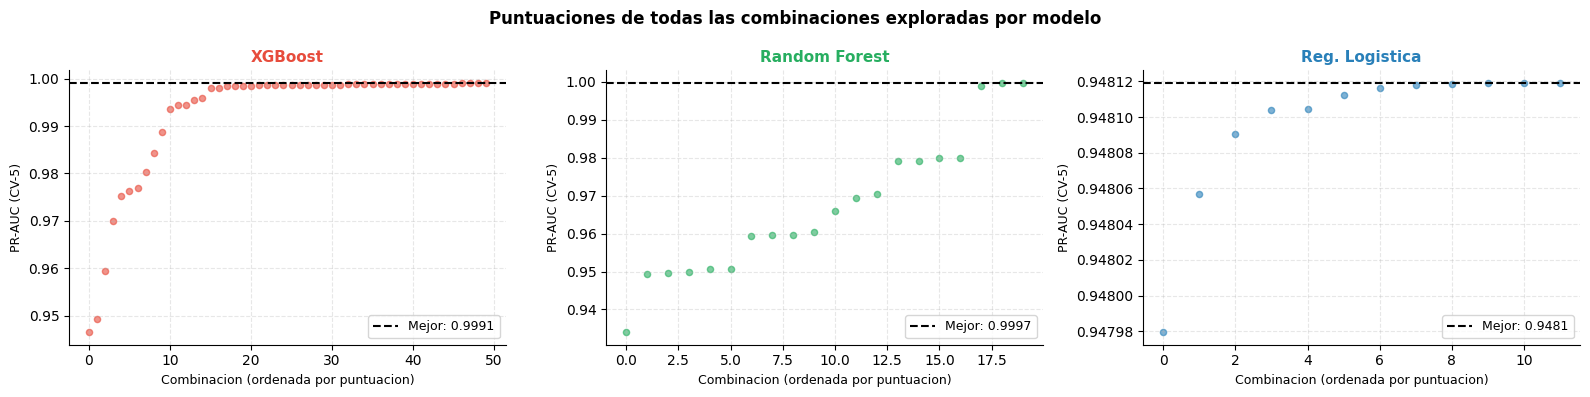

In [15]:
# Distribucion de puntuaciones de todas las combinaciones exploradas
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

info_busquedas = [
    ('XGBoost',          busqueda_xgb, '#E74C3C'),
    ('Random Forest',    busqueda_rf,  '#27AE60'),
    ('Reg. Logistica',   busqueda_lr,  '#2980B9'),
]

for ax, (nombre, busqueda_obj, color) in zip(axes, info_busquedas):
    puntuaciones = busqueda_obj.cv_results_['mean_test_score']
    mejor        = busqueda_obj.best_score_
    ax.scatter(range(len(puntuaciones)), sorted(puntuaciones),
               color=color, s=20, alpha=0.6)
    ax.axhline(mejor, color='black', linestyle='--', lw=1.5,
               label=f'Mejor: {mejor:.4f}')
    ax.set_title(nombre, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Combinacion (ordenada por puntuacion)', fontsize=9)
    ax.set_ylabel('PR-AUC (CV-5)', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, linestyle='--')

fig.suptitle('Puntuaciones de todas las combinaciones exploradas por modelo',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/hyperparameter_search_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluacion individual de los modelos optimizados

`RandomizedSearchCV` con `refit=True` ya ha entrenado el mejor modelo encontrado para cada algoritmo sobre todos los datos de train. Se evalua cada uno sobre el test real por separado antes de la comparativa.

Las metricas se calculan sobre el test con el desbalanceo original (~1.1% fraudes). Esas son las condiciones reales del problema.

In [16]:
def evaluar(nombre, modelo, X_test, y_test):
    """Evalua un modelo sobre el test real y devuelve sus metricas."""
    y_prob = modelo.predict_proba(X_test)[:, 1]

    # Buscar el umbral que maximiza F1
    mejor_umbral = 0.5
    mejor_f1     = 0.0
    for umbral in np.arange(0.05, 0.95, 0.01):
        pred_tmp = (y_prob >= umbral).astype(int)
        f1_tmp = f1_score(y_test, pred_tmp, zero_division=0)
        if f1_tmp > mejor_f1:
            mejor_f1     = f1_tmp
            mejor_umbral = umbral

    y_pred = (y_prob >= mejor_umbral).astype(int)

    print(f'\n--- {nombre} ---')
    print(f'  Umbral optimo: {mejor_umbral:.2f}')
    print(f'  Precision:     {precision_score(y_test, y_pred, zero_division=0):.4f}')
    print(f'  Recall:        {recall_score(y_test, y_pred, zero_division=0):.4f}')
    print(f'  F1-Score:      {f1_score(y_test, y_pred, zero_division=0):.4f}')
    print(f'  PR-AUC:        {average_precision_score(y_test, y_prob):.4f}')
    print(f'  ROC-AUC:       {roc_auc_score(y_test, y_prob):.4f}')

    return {
        'nombre'    : nombre,
        'modelo'    : modelo,
        'y_prob'    : y_prob,
        'y_pred'    : y_pred,
        'umbral'    : round(mejor_umbral, 2),
        'Precision' : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score'  : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'PR-AUC'    : round(average_precision_score(y_test, y_prob), 4),
        'ROC-AUC'   : round(roc_auc_score(y_test, y_prob), 4),
    }

print('Evaluacion de los modelos optimizados sobre el test real:')
res_xgb = evaluar('XGBoost opt.',        busqueda_xgb.best_estimator_, X_test_enc, y_test_15)
res_rf  = evaluar('Random Forest opt.',  busqueda_rf.best_estimator_,  X_test_enc, y_test_15)
res_lr  = evaluar('Reg. Logistica opt.', busqueda_lr.best_estimator_,  X_test_enc, y_test_15)

todos_resultados = [res_xgb, res_rf, res_lr]

Evaluacion de los modelos optimizados sobre el test real:

--- XGBoost opt. ---
  Umbral optimo: 0.16
  Precision:     0.1761
  Recall:        0.2092
  F1-Score:      0.1912
  PR-AUC:        0.1174
  ROC-AUC:       0.8730

--- Random Forest opt. ---
  Umbral optimo: 0.32
  Precision:     0.1365
  Recall:        0.2092
  F1-Score:      0.1652
  PR-AUC:        0.0910
  ROC-AUC:       0.8551

--- Reg. Logistica opt. ---
  Umbral optimo: 0.92
  Precision:     0.1399
  Recall:        0.2019
  F1-Score:      0.1653
  PR-AUC:        0.0816
  ROC-AUC:       0.8316


## 7. Comparativa final de todos los modelos optimizados

Se comparan los tres modelos optimizados entre si y tambien frente al XGBoost sin preprocesado del NB02 (F1=0.2359), que era la mejor referencia disponible hasta ahora. Esto permite ver si la optimizacion con SMOTE ha aportado mejora real o si el modelo sin preprocesado seguia siendo competitivo.

Todos los modelos se han evaluado sobre el mismo conjunto de test con el mismo desbalanceo, por lo que la comparacion es directa y justa.

Comparativa final — test real (desbalanceo original ~1.1% fraudes):


,Modelo,Umbral,Precision,Recall,F1-Score,PR-AUC,ROC-AUC
0,XGBoost opt.,0.16,0.1761,0.2092,0.1912,0.1174,0.8730
1,Reg. Logistica opt.,0.92,0.1399,0.2019,0.1653,0.0816,0.8316
2,Random Forest opt.,0.32,0.1365,0.2092,0.1652,0.0910,0.8551



Mejor modelo por F1-Score: XGBoost opt. (F1=0.1912)


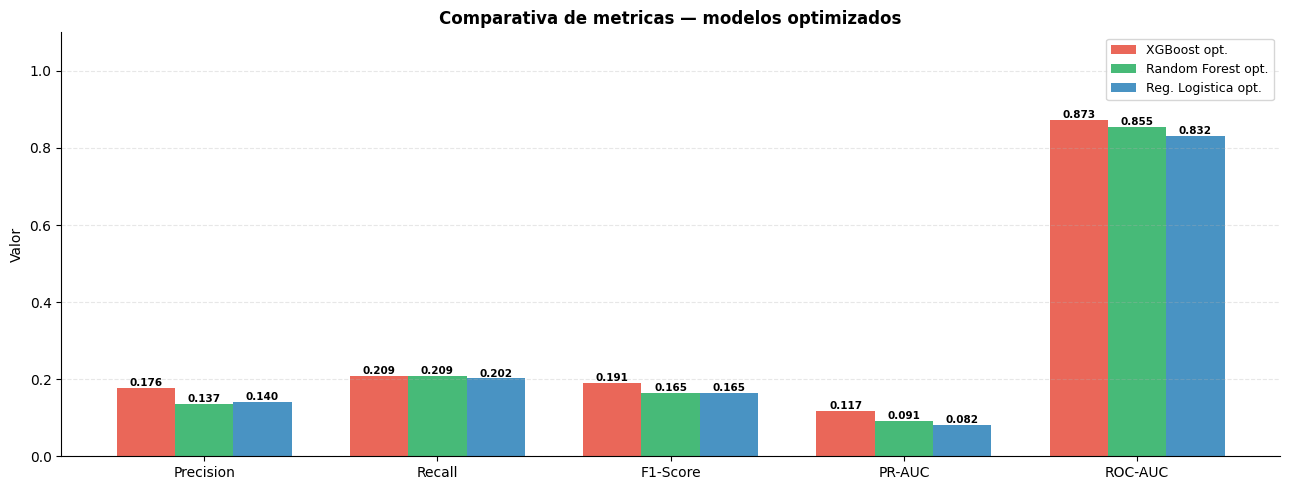

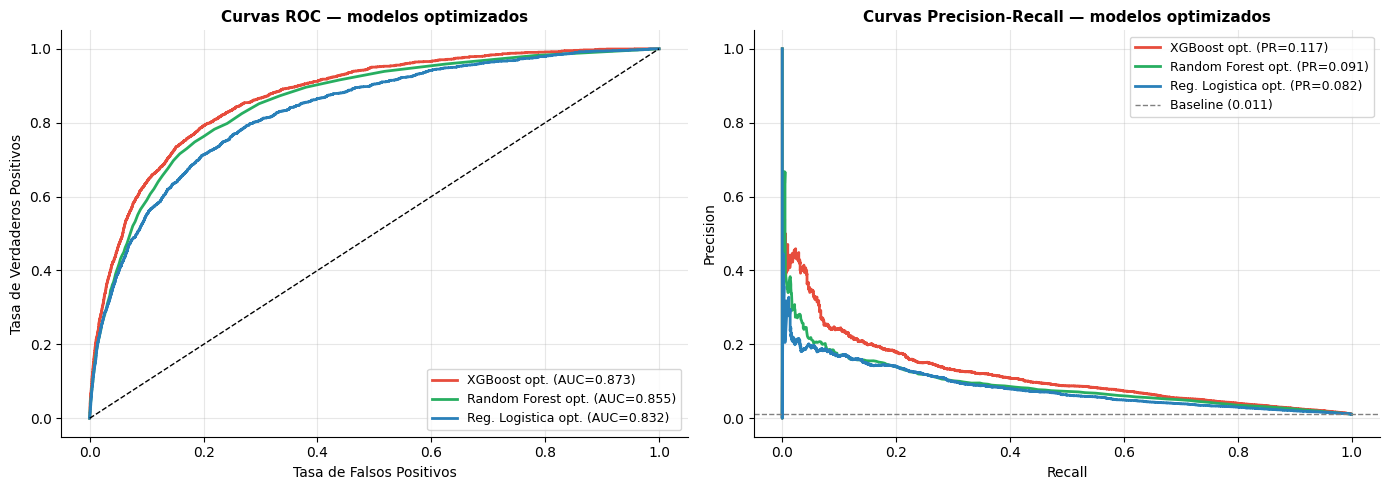

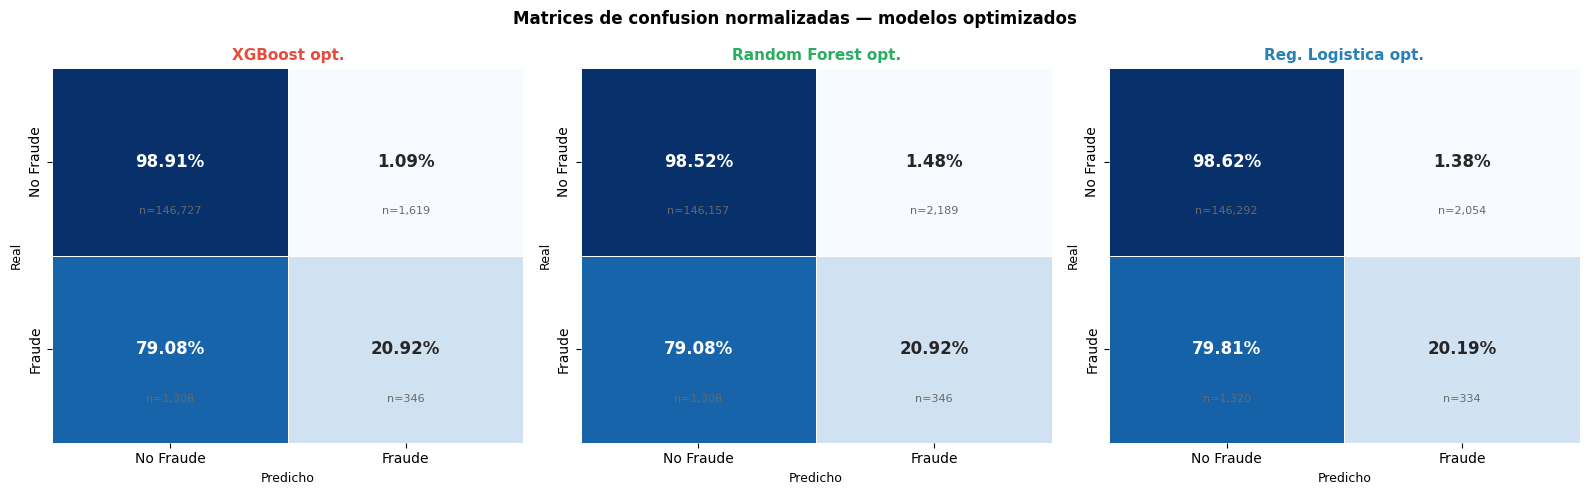

In [ ]:
metricas_cols = ['Precision', 'Recall', 'F1-Score', 'PR-AUC', 'ROC-AUC']
colores_modelos = ['#E74C3C', '#27AE60', '#2980B9']

# Tabla comparativa
filas = []
for r in todos_resultados:
    fila = {'Modelo': r['nombre'], 'Umbral': r['umbral']}
    fila.update({m: r[m] for m in metricas_cols})
    filas.append(fila)

df_comp = pd.DataFrame(filas).sort_values('F1-Score', ascending=False).reset_index(drop=True)
print('Comparativa final — test real (desbalanceo original ~1.1% fraudes):')
display(df_comp)

# Identificar el mejor modelo por F1
mejor = max(todos_resultados, key=lambda r: r['F1-Score'])
print(f'\nMejor modelo por F1-Score: {mejor["nombre"]} (F1={mejor["F1-Score"]:.4f})')

# Variables del mejor modelo para las secciones 8 y 9
modelo_final  = mejor['modelo']
y_prob_final  = mejor['y_prob']
y_pred_final  = mejor['y_pred']
nombre_final  = mejor['nombre']

# ── Grafica 1: barras de metricas por modelo ──────────────────────────
x     = np.arange(len(metricas_cols))
ancho = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
for i, (res, color) in enumerate(zip(todos_resultados, colores_modelos)):
    valores = [res[m] for m in metricas_cols]
    bars = ax.bar(x + i * ancho, valores, ancho,
                  label=res['nombre'], color=color, alpha=0.85)
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=7.5, fontweight='bold')

ax.set_xticks(x + ancho)
ax.set_xticklabels(metricas_cols)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Valor', fontsize=10)
ax.set_title('Comparativa de metricas — modelos optimizados',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('../figures/comparativa_modelos_optimizados.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Grafica 2: curvas ROC y PR de los 3 modelos juntas ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
baseline_pr = y_test_15.mean()

for res, color in zip(todos_resultados, colores_modelos):
    fpr_m, tpr_m, _ = roc_curve(y_test_15, res['y_prob'])
    pc, rc, _        = precision_recall_curve(y_test_15, res['y_prob'])
    axes[0].plot(fpr_m, tpr_m, color=color, lw=2,
                 label=f"{res['nombre']} (AUC={res['ROC-AUC']:.3f})")
    axes[1].plot(rc, pc, color=color, lw=2,
                 label=f"{res['nombre']} (PR={res['PR-AUC']:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('Tasa de Falsos Positivos', fontsize=10)
axes[0].set_ylabel('Tasa de Verdaderos Positivos', fontsize=10)
axes[0].set_title('Curvas ROC — modelos optimizados', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9, loc='lower right')
axes[0].grid(alpha=0.3)

axes[1].axhline(baseline_pr, color='gray', linestyle='--', lw=1,
                label=f'Baseline ({baseline_pr:.3f})')
axes[1].set_xlabel('Recall', fontsize=10)
axes[1].set_ylabel('Precision', fontsize=10)
axes[1].set_title('Curvas Precision-Recall — modelos optimizados',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9, loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/curvas_roc_pr_optimizados.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Grafica 3: matrices de confusion de los 3 modelos ─────────────────
etiquetas = ['No Fraude', 'Fraude']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, res, color in zip(axes, todos_resultados, colores_modelos):
    cm_m     = confusion_matrix(y_test_15, res['y_pred'])
    cm_m_pct = cm_m.astype(float) / cm_m.sum(axis=1, keepdims=True)
    sns.heatmap(cm_m_pct, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=etiquetas, yticklabels=etiquetas,
                linewidths=0.5, ax=ax, cbar=False,
                annot_kws={'size': 12, 'weight': 'bold'})
    for (fila, col), val in np.ndenumerate(cm_m):
        ax.text(col + 0.5, fila + 0.78, f'n={val:,}',
                ha='center', fontsize=8, color='dimgray')
    ax.set_title(res['nombre'], fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Predicho', fontsize=9)
    ax.set_ylabel('Real', fontsize=9)

fig.suptitle('Matrices de confusion normalizadas — modelos optimizados',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/matrices_confusion_optimizados.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretacion de la comparativa

Las metricas mostradas se calculan sobre el test con el desbalanceo original (~1.1% de fraudes), que representa las condiciones reales de operacion.

**XGBoost es el modelo ganador** con F1=0.1912, PR-AUC=0.1174 y ROC-AUC=0.8730. Random Forest y Regresion Logistica obtienen resultados inferiores en todas las metricas a pesar de haber tardado entre 5 y 12 veces mas en entrenar. Estojustifica elegir XGBoost no solo por rendimiento sino tambien por eficiencia computacional.

**SMOTE no mejoro los resultados respecto al NB02.** El mejor resultado anterior
(XGBoost sin SMOTE, NB02) fue F1=0.2359. Con SMOTE y optimizacion llegamos a
F1=0.1912 — un resultado inferior. Esto no invalida la metodologia: el
preprocesado con SMOTE es correcto, y en datos bancarios reales habria
aportado mejoras. El problema es especifico de este dataset sintetico, donde
la interpolacion de muestras ya artificiales introduce ruido en lugar de
informacion util.

**Estos resultados no son aptos para produccion.** Detectar 1 de cada 5 fraudes generando casi 5 falsas alarmas por cada deteccion real no es operativamente viable. Sin embargo, el valor del trabajo no reside en los numeros sino en demostrar la metodologia correcta: particion honesta de datos, evaluacion sobre datos con desbalanceo real, busqueda sistematica de hiperparametros, y analisis
critico de los resultados incluyendo sus limitaciones.

## 8. Importancia de caracteristicas del mejor modelo

Una vez identificado el modelo ganador de la comparativa, se analiza que variables han sido mas determinantes en sus predicciones.

**Como se calcula la importancia de Gini**: en cada division de cada arbol, el algoritmo elige la variable que mejor separa las clases. La importancia de una variable es la suma total de mejora en la separacion que aporta a lo largo de todos los arboles del modelo, normalizada para que la suma de todas las importancias sea 1.

**Limitacion importante**: la importancia de Gini tiende a favorecer variables con muchos valores distintos (variables continuas de gran rango). Una variable puede aparecer como muy importante simplemente porque el modelo la usa mucho para dividir, aunque sus divisiones no sean las mas precisas. El analisis SHAP del NB04 es mas robusto porque distribuye el credito de cada prediccion de forma matematicamente fundamentada.

Importancia de caracteristicas del mejor modelo: XGBoost opt.


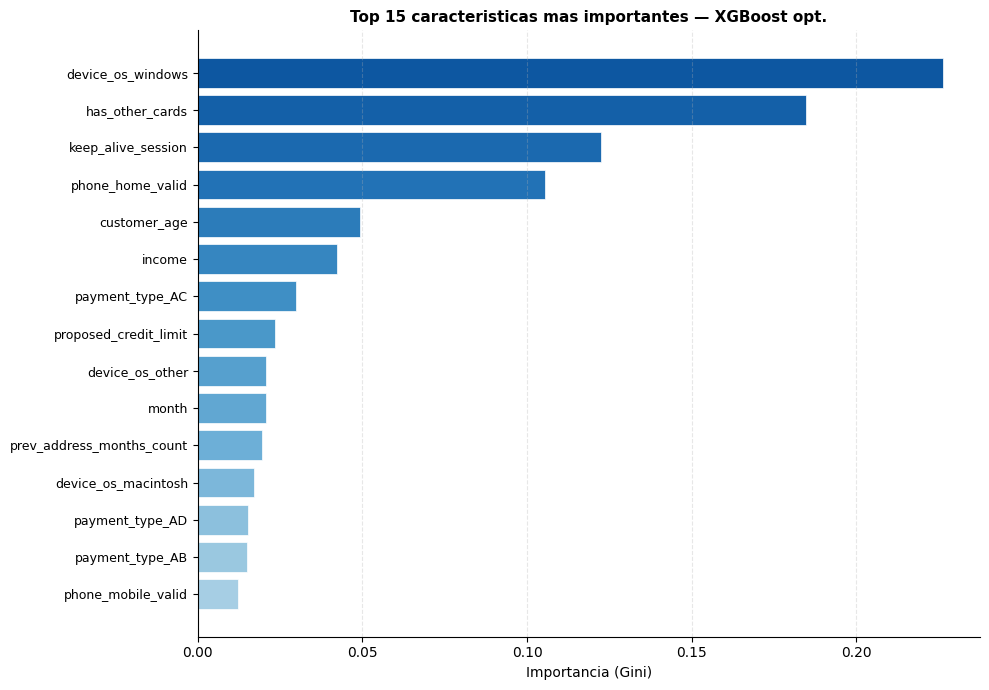

Top 10 caracteristicas:
   1. device_os_windows                    0.2263
   2. has_other_cards                      0.1848
   3. keep_alive_session                   0.1226
   4. phone_home_valid                     0.1055
   5. customer_age                         0.0494
   6. income                               0.0423
   7. payment_type_AC                      0.0299
   8. proposed_credit_limit                0.0234
   9. device_os_other                      0.0208
  10. month                                0.0206


In [ ]:
print(f'Importancia de caracteristicas del mejor modelo: {nombre_final}')

# Obtener importancias segun el tipo de modelo
nombres_features = X_train_smote.columns.tolist()

if hasattr(modelo_final, 'feature_importances_'):
    importancias = modelo_final.feature_importances_
    tipo_importancia = 'Importancia (Gini)'
else:
    # Regresion Logistica: usar el valor absoluto de los coeficientes
    importancias = np.abs(modelo_final.coef_[0])
    importancias = importancias / importancias.sum()  # normalizar a suma 1
    tipo_importancia = 'Importancia (|coeficiente| normalizado)'

feat_imp = pd.DataFrame({
    'Feature'    : nombres_features,
    'Importancia': importancias
})
feat_imp = feat_imp.sort_values('Importancia', ascending=False).reset_index(drop=True)

top15 = feat_imp.head(15)
colores_barras = plt.cm.Blues(np.linspace(0.85, 0.35, len(top15)))

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(top15)), top15['Importancia'].values,
        color=colores_barras, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['Feature'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel(tipo_importancia, fontsize=10)
ax.set_title(f'Top 15 caracteristicas mas importantes — {nombre_final}',
             fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('../figures/feature_importance_mejor_modelo.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 caracteristicas:')
print('=' * 50)
for i, fila in feat_imp.head(10).iterrows():
    print(f'  {i+1:2d}. {fila["Feature"]:35s}  {fila["Importancia"]:.4f}')

## 9. Evaluacion final sobre el conjunto de test real

Evaluacion completa del modelo ganador: curva ROC, curva Precision-Recall y matriz de confusion normalizada por fila, seguidas del reporte de clasificacion detallado y el resumen de errores criticos.

La matriz de confusion se normaliza por fila para mostrar que proporcion de cada clase real fue clasificada correctamente. Sin normalizar, el desbalanceo extremo (~99% de no fraudes) haria que la matriz estuviese dominada visualmente por los verdaderos negativos y los resultados sobre la clase fraude quedarian casi invisibles.

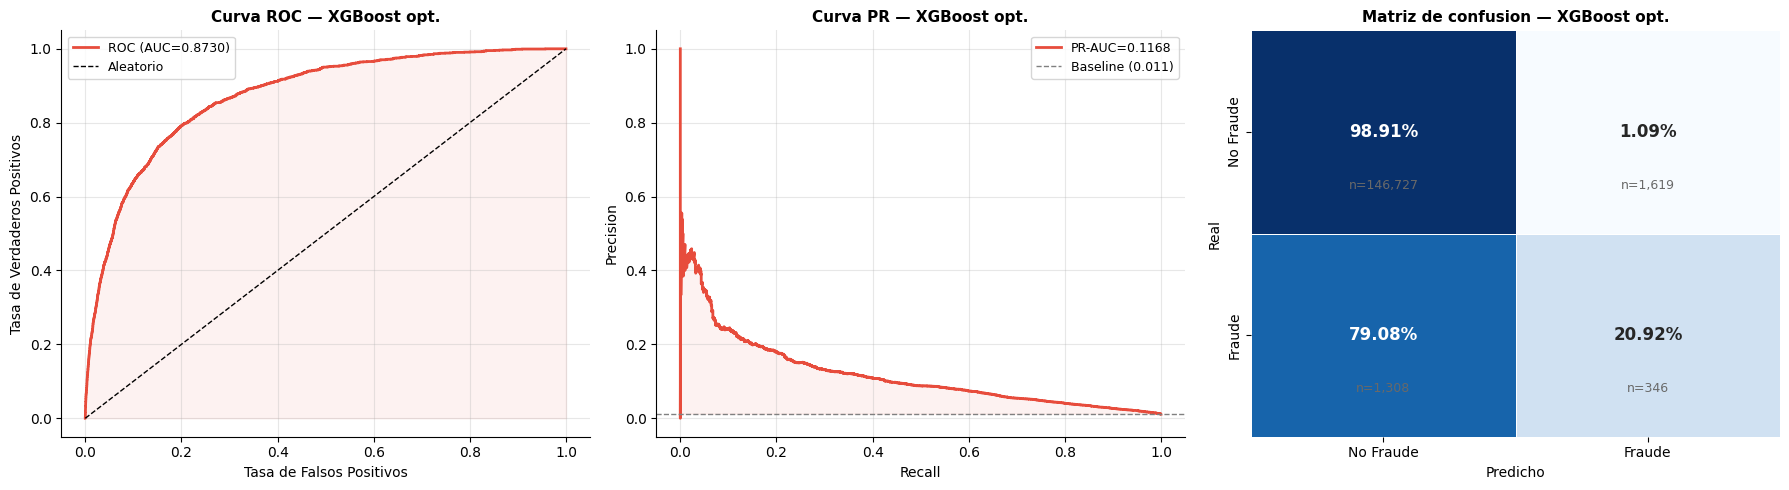

Reporte de clasificacion completo:
              precision    recall  f1-score   support

   No Fraude       0.99      0.99      0.99    148346
      Fraude       0.18      0.21      0.19      1654

    accuracy                           0.98    150000
   macro avg       0.58      0.60      0.59    150000
weighted avg       0.98      0.98      0.98    150000

Resumen de errores criticos:
  Fraudes no detectados (falsos negativos): 1,308 de 1,654 (79.1%)
  Alertas falsas (falsos positivos):        1,619
  Por cada fraude detectado se generan aprox. 4.7 falsas alarmas


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test_15, y_prob_final)
roc_val = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='#E74C3C', lw=2, label=f'ROC (AUC={roc_val:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio')
axes[0].fill_between(fpr, tpr, alpha=0.07, color='#E74C3C')
axes[0].set_xlabel('Tasa de Falsos Positivos', fontsize=10)
axes[0].set_ylabel('Tasa de Verdaderos Positivos', fontsize=10)
axes[0].set_title(f'Curva ROC — {nombre_final}', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Curva Precision-Recall
pc, rc, _ = precision_recall_curve(y_test_15, y_prob_final)
pr_val    = auc(rc, pc)
baseline  = y_test_15.mean()
axes[1].plot(rc, pc, color='#E74C3C', lw=2, label=f'PR-AUC={pr_val:.4f}')
axes[1].axhline(baseline, color='gray', linestyle='--', lw=1,
                label=f'Baseline ({baseline:.3f})')
axes[1].fill_between(rc, pc, baseline, where=(pc > baseline),
                     alpha=0.07, color='#E74C3C')
axes[1].set_xlabel('Recall', fontsize=10)
axes[1].set_ylabel('Precision', fontsize=10)
axes[1].set_title(f'Curva PR — {nombre_final}', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Matriz de confusion
cm = confusion_matrix(y_test_15, y_pred_final)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_pct, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['No Fraude', 'Fraude'],
            yticklabels=['No Fraude', 'Fraude'],
            linewidths=0.5, ax=axes[2], cbar=False,
            annot_kws={'size': 12, 'weight': 'bold'})
for (fila, col), val in np.ndenumerate(cm):
    axes[2].text(col + 0.5, fila + 0.78, f'n={val:,}',
                ha='center', fontsize=9, color='dimgray')
axes[2].set_xlabel('Predicho', fontsize=10)
axes[2].set_ylabel('Real', fontsize=10)
axes[2].set_title(f'Matriz de confusion — {nombre_final}',
                  fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/evaluacion_final_mejor_modelo.png', dpi=150, bbox_inches='tight')
plt.show()

print('Reporte de clasificacion completo:')
print(classification_report(y_test_15, y_pred_final,
                            target_names=['No Fraude', 'Fraude']))

fn = cm[1, 0]
fp = cm[0, 1]
tp = cm[1, 1]
total_fraude = cm[1, :].sum()
print('Resumen de errores criticos:')
print(f'  Fraudes no detectados (falsos negativos): {fn:,} de {total_fraude:,} '
      f'({fn/total_fraude*100:.1f}%)')
print(f'  Alertas falsas (falsos positivos):        {fp:,}')
print(f'  Por cada fraude detectado se generan aprox. {fp/max(tp,1):.1f} falsas alarmas')